# Column 06 - Cross-sectional rotation and portfolio construction

This notebook turns De-Time features into a portfolio ranking language: trend decides direction, cycle adjusts timing, residual controls overextension and volume/reconstruction features control reliability.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from quant_trading.data import load_bundled_real_ohlcv_panel, ohlcv_audit_report
from quant_trading.features import walkforward_decompose_ohlcv
from quant_trading.decomposition_features import feature_coverage_report, build_feature_table
from quant_trading.strategy_baselines import buy_and_hold_weights
from quant_trading.strategy_rotation import (
    classic_momentum_rotation_weights, detime_cross_sectional_score,
    detime_long_short_rotation_weights, detime_rotation_weights,
    rotation_diagnostic_table, volume_availability,
)
from quant_trading.validation import compare_weight_strategies, turnover_report

## 1. Load real offline market data

In [2]:
tickers = ["AUDUSD=X", "NZDUSD=X", "EURUSD=X", "GBPUSD=X"]
ohlcv = load_bundled_real_ohlcv_panel(tickers, min_observations=120)
ohlcv = {field: table.tail(280).copy() for field, table in ohlcv.items()}
prices = ohlcv["Close"]
volumes = ohlcv.get("Volume")
print("volume_available:", volume_availability(volumes))
ohlcv_audit_report(ohlcv)

volume_available: False


,ticker,first_timestamp,last_timestamp,observations,close_missing_ratio,volume_missing_ratio,zero_volume_ratio,min_close,max_close,median_volume
0,AUDUSD=X,2016-12-05,2018-01-02,280,0.0,0.0,1.0,0.717927,0.805802,0.0
1,NZDUSD=X,2016-12-05,2018-01-02,280,0.0,0.0,1.0,0.680101,0.752570,0.0
2,EURUSD=X,2016-12-05,2018-01-02,280,0.0,0.0,1.0,1.039047,1.202906,0.0
3,GBPUSD=X,2016-12-05,2018-01-02,280,0.0,0.0,1.0,1.203935,1.357976,0.0


## 2. Build walk-forward asset features

In [3]:
features = walkforward_decompose_ohlcv(
    ohlcv, method="STL", period=42, train_window=180, step=252, z_window=42
)
feature_coverage_report(features).query("feature in ['trend_slope', 'trend_strength', 'cycle_slope', 'residual_z', 'residual_abs_z', 'volume_participation']").head(18)

,feature,asset,observations,non_null,coverage,first_valid,last_valid
12,trend_slope,AUDUSD=X,280,101,0.360714,2017-08-14,2018-01-02
13,trend_slope,NZDUSD=X,280,101,0.360714,2017-08-14,2018-01-02
14,trend_slope,EURUSD=X,280,101,0.360714,2017-08-14,2018-01-02
15,trend_slope,GBPUSD=X,280,101,0.360714,2017-08-14,2018-01-02
20,trend_strength,AUDUSD=X,280,101,0.360714,2017-08-14,2018-01-02
21,trend_strength,NZDUSD=X,280,101,0.360714,2017-08-14,2018-01-02
22,trend_strength,EURUSD=X,280,101,0.360714,2017-08-14,2018-01-02
23,trend_strength,GBPUSD=X,280,101,0.360714,2017-08-14,2018-01-02
32,cycle_slope,AUDUSD=X,280,101,0.360714,2017-08-14,2018-01-02
33,cycle_slope,NZDUSD=X,280,101,0.360714,2017-08-14,2018-01-02


In [4]:
build_feature_table(prices, features).tail(3).iloc[:, :12].round(4)

component_stability                               cycle           \
                      AUDUSD=X EURUSD=X GBPUSD=X NZDUSD=X AUDUSD=X EURUSD=X   
Date                                                                          
2017-12-29              0.9957   0.9971   0.9952   0.9949  -0.0068   0.0028   
2018-01-01              0.9957   0.9971   0.9952   0.9949  -0.0068   0.0028   
2018-01-02              0.9957   0.9971   0.9952   0.9949  -0.0068   0.0028   

                             cycle_amplitude                             
           GBPUSD=X NZDUSD=X        AUDUSD=X EURUSD=X GBPUSD=X NZDUSD=X  
Date                                                                     
2017-12-29  -0.0089   -0.015          0.0102   0.0086   0.0091   0.0108  
2018-01-01  -0.0089   -0.015          0.0102   0.0086   0.0091   0.0108  
2018-01-02  -0.0089   -0.015          0.0102   0.0086   0.0091   0.0108

## 3. Inspect the De-Time rotation score

In [5]:
score = detime_cross_sectional_score(prices, features)
score.tail(5).round(3)

,AUDUSD=X,NZDUSD=X,EURUSD=X,GBPUSD=X
Date,,,,
2017-12-27,2.356,1.256,2.481,1.031
2017-12-28,2.356,1.256,2.481,1.031
2017-12-29,2.356,1.256,2.481,1.031
2018-01-01,2.356,1.256,2.481,1.031
2018-01-02,2.356,1.256,2.481,1.031


In [6]:
rotation_diagnostic_table(prices, features, tail=2).round(4)

,date,asset,score,trend_strength,cycle_slope,residual_z,volume_participation
0,2018-01-01,EURUSD=X,2.4812,0.2403,0.0007,0.9507,1.25
1,2018-01-01,AUDUSD=X,2.3562,0.2955,-0.0003,-1.0228,1.25
2,2018-01-01,NZDUSD=X,1.2562,0.1906,-0.0007,-2.3371,1.25
3,2018-01-01,GBPUSD=X,1.0313,0.1049,0.0006,0.9669,1.25
4,2018-01-02,EURUSD=X,2.4812,0.2403,0.0007,0.9507,1.25
5,2018-01-02,AUDUSD=X,2.3562,0.2955,-0.0003,-1.0228,1.25
6,2018-01-02,NZDUSD=X,1.2562,0.1906,-0.0007,-2.3371,1.25
7,2018-01-02,GBPUSD=X,1.0313,0.1049,0.0006,0.9669,1.25


## 4. Backtest a compact rotation suite

In [7]:
strategies = {
    "buy_hold_equal_weight": buy_and_hold_weights(prices),
    "classic_momentum_63_top": classic_momentum_rotation_weights(prices, lookback=63, top_n=2, rebalance_freq="W-FRI", vol_target=None),
    "detime_rotation_top_trend_cycle_residual_volume": detime_rotation_weights(prices, features, top_n=2, rebalance_freq="W-FRI", vol_target=None),
    "detime_rotation_long_short": detime_long_short_rotation_weights(prices, features, top_n=2, bottom_n=2),
}
comparison, results = compare_weight_strategies(prices, strategies, fee_bps=1.0, slippage_bps=2.0)
comparison[["total_return", "sharpe", "max_drawdown", "average_turnover"]].round(4)

,total_return,sharpe,max_drawdown,average_turnover
strategy,,,,
buy_hold_equal_weight,0.0624,0.9200,-0.0428,0.0000
classic_momentum_63_top,0.0356,0.5964,-0.0518,0.0464
detime_rotation_top_trend_cycle_residual_volume,0.0429,0.5756,-0.0533,0.0071
detime_rotation_long_short,-0.0729,-0.7004,-0.1366,0.0162


## 5. Visualize rotation scores and after-cost equity

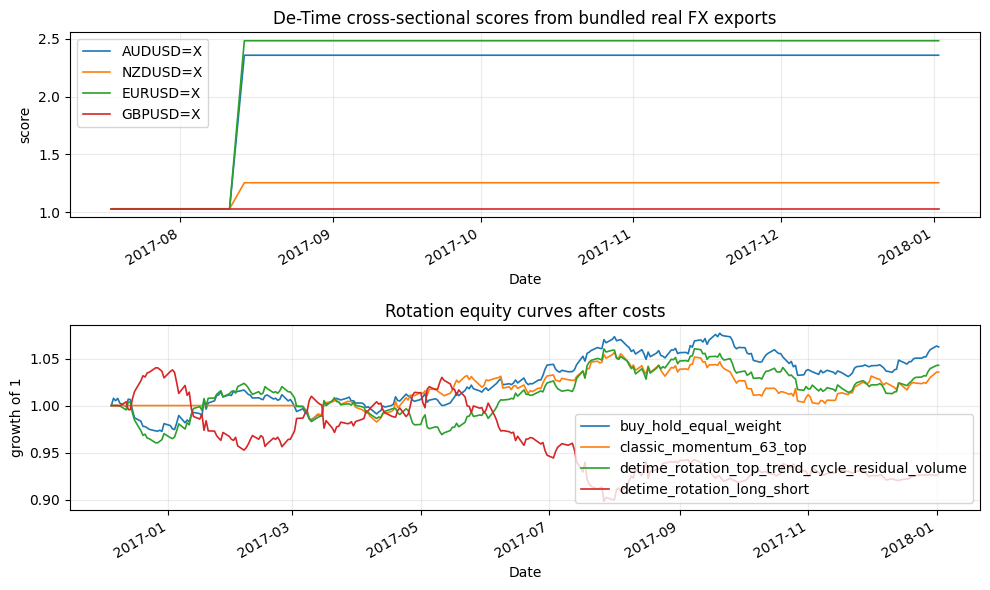

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False)
score.tail(120).plot(ax=axes[0], linewidth=1.2)
axes[0].set_title("De-Time cross-sectional scores from bundled real FX exports")
axes[0].set_ylabel("score")

equity_curves = pd.DataFrame({name: result.equity for name, result in results.items()})
equity_curves.plot(ax=axes[1], linewidth=1.2)
axes[1].set_title("Rotation equity curves after costs")
axes[1].set_ylabel("growth of 1")
for ax in axes:
    ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

In [9]:
turnover_report(strategies).round(4)

,average_turnover,median_turnover,max_turnover,average_gross_exposure
strategy,,,,
buy_hold_equal_weight,0.0000,0.0,0.00,1.0000
classic_momentum_63_top,0.0464,0.0,1.00,0.7714
detime_rotation_top_trend_cycle_residual_volume,0.0071,0.0,1.00,0.9857
detime_rotation_long_short,0.0162,0.0,2.25,1.4384


## 5. Live-data extension

Run `run_column_06_cross_sectional_rotation.py` without `--use-bundled-sample` to use sector ETFs and real equity/ETF volume. In the bundled FX sample, raw volume is unavailable, so volume is neutral rather than invented.